In [1]:
from __future__ import annotations

from os import PathLike
from typing import Any, Literal, Sequence
from types import EllipsisType

import numpy as np
from numpy.typing import DTypeLike

from pyflim.PTU.reader import PTUFile, PTUArray5D
from phasorpy.phasor import phasor_from_signal

In [2]:
from pyflim.PTU.tools import signal_from_PTUFile

In [10]:
# Load with spatial binning to boost photon counts per pixel
signal = signal_from_PTUFile('TTTT.ptu', dtype=np.uint32, binning=4)
print(f"shape:  {signal.shape}")
print(f"dims:   {signal.dims}")
print(f"dtype:  {signal.dtype}")
print(f"freq:   {signal.attrs['frequency']:.2f} MHz")
if 'H' in signal.coords:
    print(f"H range: {float(signal.coords['H'][0]):.2f} – {float(signal.coords['H'][-1]):.2f} ns")

shape:  (1, 256, 256, 529)
dims:   ('T', 'Y', 'X', 'H')
dtype:  uint32
freq:   19.50 MHz
H range: 0.05 – 51.25 ns


In [11]:
# H (histogram) is the last axis — tell phasor_from_signal to use it
mean, real, imag = phasor_from_signal(signal, axis='H')
print(f"phasor mean shape: {mean.shape}")
print(f"phasor mean min/max: {np.nanmin(mean):.2f} / {np.nanmax(mean):.2f}")
print(f"phasor real min/max: {np.nanmin(real):.4f} / {np.nanmax(real):.4f}")
print(f"phasor imag min/max: {np.nanmin(imag):.4f} / {np.nanmax(imag):.4f}")

phasor mean shape: (1, 256, 256)
phasor mean min/max: 0.00 / 0.18
phasor real min/max: -0.9545 / 0.9490
phasor imag min/max: -0.2983 / 0.9995


In [12]:
import pandas as pd
from phasorpy.phasor import phasor_to_polar, phasor_transform

# ── Read IRF from the spreadsheet ──
df = pd.read_excel('TTTT.xlsx', sheet_name='Fit', header=None)
irf_time_ns = pd.to_numeric(df.iloc[2:, 2], errors='coerce').dropna().values
irf_counts  = pd.to_numeric(df.iloc[2:, 3], errors='coerce').dropna().values

# ── Interpolate IRF onto the signal's time axis (zeros outside IRF range) ──
signal_time_ns = signal.coords['H'].values
irf_on_signal = np.interp(signal_time_ns, irf_time_ns, irf_counts, left=0, right=0)

# ── Compute the IRF phasor (should be near (1,0) for a delta function) ──
mean_irf, real_irf, imag_irf = phasor_from_signal(
    irf_on_signal[np.newaxis, :], axis=-1
)
phase_irf, mod_irf = phasor_to_polar(real_irf.ravel(), imag_irf.ravel())

print(f"IRF phasor:  G={real_irf.ravel()[0]:.4f}  S={imag_irf.ravel()[0]:.4f}")
print(f"IRF polar:   phase={phase_irf[0]:.4f} rad  mod={mod_irf[0]:.4f}")

IRF phasor:  G=0.9432  S=0.3321
IRF polar:   phase=0.3386 rad  mod=0.9999


In [13]:
# ── Calibrate: rotate by -phase_irf, scale by 1/mod_irf ──
# This shifts the IRF phasor to (1, 0) and corrects the sample accordingly
real_cal, imag_cal = phasor_transform(
    real, imag,
    -phase_irf[0], 1.0 / mod_irf[0],
)

print(f"Calibrated real min/max: {np.nanmin(real_cal):.4f} / {np.nanmax(real_cal):.4f}")
print(f"Calibrated imag min/max: {np.nanmin(imag_cal):.4f} / {np.nanmax(imag_cal):.4f}")

Calibrated real min/max: -0.9994 / 1.0000
Calibrated imag min/max: -0.0179 / 0.9536


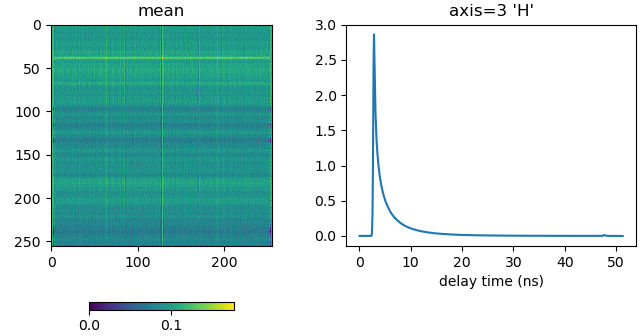

In [14]:
from phasorpy.plot import plot_signal_image

plot_signal_image(signal, axis='H', xlabel='delay time (ns)')

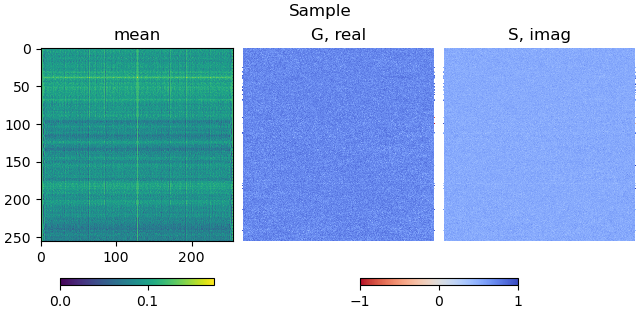

In [15]:
from phasorpy.plot import plot_phasor_image

plot_phasor_image(mean, real, imag, title='Sample')

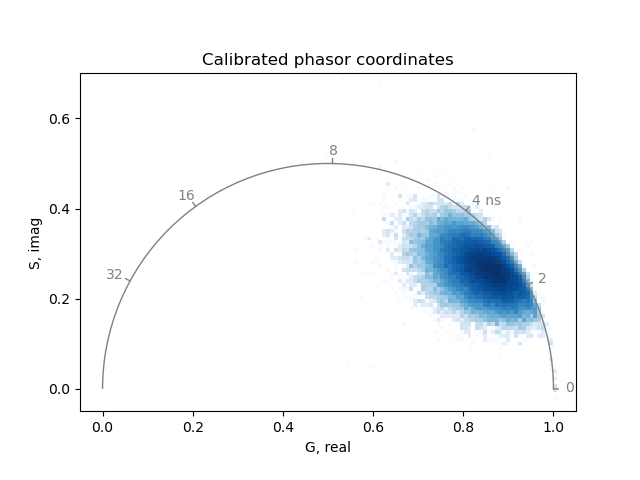

In [16]:
from phasorpy.plot import plot_phasor

frequency = signal.attrs['frequency']

plot_phasor(
    real_cal,
    imag_cal,
    frequency=frequency,
    title='Calibrated phasor coordinates',
)

In [ ]:
%matplotlib widget
import matplotlib
matplotlib.use('module://ipympl.backend_nbagg')   # force ipympl

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import ipywidgets as widgets
from IPython.display import display, clear_output
from phasorpy.lifetime import phasor_to_apparent_lifetime
from scipy.optimize import minimize_scalar
import numpy as np

# ── Pre-compute 2D arrays ──
frequency = signal.attrs['frequency']    # MHz
rc = real_cal.squeeze().astype(float)
ic = imag_cal.squeeze().astype(float)
mn = mean.squeeze().astype(float)
min_photons = 0.01
valid = (mn >= min_photons) & ~np.isnan(rc)

# Angular frequency in rad/ns  (frequency is MHz; × 1e-3 → GHz = cycles/ns)
omega = 2 * np.pi * frequency * 1e-3

# ── Semicircle helpers ──
def tau_to_phasor(tau):
    """Single-exponential lifetime → (G, S) on the semicircle."""
    wt = omega * tau
    g = 1.0 / (1.0 + wt**2)
    s = wt  / (1.0 + wt**2)
    return g, s

def line_semicircle_intersections(g1, s1, g2, s2):
    """Find the two τ values where a line intersects the universal semicircle.
    
    Semicircle:  (G - 0.5)² + S² = 0.25,  S >= 0
    Line:  P(t) = (1-t)·(g1,s1) + t·(g2,s2)
    Returns sorted (tau_short, tau_long) or None.
    """
    dg = g2 - g1; ds = s2 - s1
    # Substitute into circle eqn → quadratic in t
    a = dg**2 + ds**2
    b = 2*((g1 - 0.5)*dg + s1*ds)
    c = (g1 - 0.5)**2 + s1**2 - 0.25
    disc = b**2 - 4*a*c
    if disc < 0 or a < 1e-15:
        return None
    sq = np.sqrt(disc)
    taus = []
    for t in [(-b - sq)/(2*a), (-b + sq)/(2*a)]:
        gi = g1 + t*dg
        si = s1 + t*ds
        if si >= -0.01 and 0 <= gi <= 1.01:
            wt = si / max(gi, 1e-12)
            tau = wt / omega
            if tau > 0:
                taus.append(tau)
    if len(taus) < 2:
        return None
    taus.sort()
    return taus[0], taus[1]

def decompose_two_component(g_sel, s_sel):
    """Find τ₁, τ₂ from the principal axis of a phasor cloud.
    
    1. PCA on the cloud → major axis direction
    2. Extend that line to hit the semicircle at two points → τ₁, τ₂
    3. Project each pixel onto the chord → fractional contribution f₂
    """
    if len(g_sel) < 5:
        return None
    gc = g_sel.mean(); sc = s_sel.mean()
    dg = g_sel - gc; ds = s_sel - sc
    cov = np.array([[np.mean(dg*dg), np.mean(dg*ds)],
                     [np.mean(ds*dg), np.mean(ds*ds)]])
    eigvals, eigvecs = np.linalg.eigh(cov)
    # Major axis = eigenvector with largest eigenvalue
    major = eigvecs[:, np.argmax(eigvals)]
    
    # Two far points along the major axis through the centroid
    ext = 2.0  # extend well past semicircle
    g_a, s_a = gc - ext*major[0], sc - ext*major[1]
    g_b, s_b = gc + ext*major[0], sc + ext*major[1]
    
    result = line_semicircle_intersections(g_a, s_a, g_b, s_b)
    if result is None:
        return None
    tau1, tau2 = result
    
    # Intersection points on semicircle
    g_t1, s_t1 = tau_to_phasor(tau1)
    g_t2, s_t2 = tau_to_phasor(tau2)
    
    # Project each pixel along the chord  t1→t2
    chord_g = g_t2 - g_t1; chord_s = s_t2 - s_t1
    chord_len2 = chord_g**2 + chord_s**2
    if chord_len2 < 1e-15:
        return None
    frac2 = ((g_sel - g_t1)*chord_g + (s_sel - s_t1)*chord_s) / chord_len2
    frac2 = np.clip(frac2, 0, 1)
    
    return dict(tau1=tau1, tau2=tau2,
                g_t1=g_t1, s_t1=s_t1, g_t2=g_t2, s_t2=s_t2,
                frac2=frac2, major=major, centroid=(gc, sc))

# ══════════════════════════════════════════════════════════════
# State
# ══════════════════════════════════════════════════════════════
state = dict(p1=None, p2=None, dragging=False,
             line_artist=None, band_artist=None, dot1=None, dot2=None)
band_width = [0.05]
results_out = widgets.Output()

def compute_and_show_results():
    p1, p2 = state['p1'], state['p2']
    if p1 is None or p2 is None:
        return
    lw = band_width[0]
    g1, s1 = p1; g2, s2 = p2
    dg = g2 - g1; ds = s2 - s1
    ll = np.sqrt(dg**2 + ds**2)
    if ll < 1e-9:
        return
    ug, us = dg/ll, ds/ll
    ng, ns_ = -us, ug

    vg = np.where(valid, rc - g1, np.nan)
    vs = np.where(valid, ic - s1, np.nan)
    t_along = (vg*ug + vs*us) / ll
    d_perp = np.abs(vg*ng + vs*ns_)
    inside = valid & (t_along >= 0) & (t_along <= 1) & (d_perp <= lw)
    n_sel = int(inside.sum())

    if n_sel == 0:
        with results_out:
            clear_output(wait=True)
            print("No pixels selected — try a wider band or different line.")
        return

    g_sel = rc[inside]
    s_sel = ic[inside]
    tau_phi_sel, tau_mod_sel = phasor_to_apparent_lifetime(g_sel, s_sel, frequency)

    # ── Two-component decomposition ──
    decomp = decompose_two_component(g_sel, s_sel)

    with results_out:
        clear_output(wait=True)

        if decomp is not None:
            n_plots = 4
        else:
            n_plots = 2
        fig2, axes2 = plt.subplots(1, n_plots, figsize=(5*n_plots, 4.5))

        # ── Panel 1: Spatial lifetime map ──
        ax_map = axes2[0]
        fmap = np.full_like(rc, np.nan, dtype=float)
        fmap[inside] = tau_phi_sel
        vmin = np.nanpercentile(tau_phi_sel, 2)
        vmax = np.nanpercentile(tau_phi_sel, 98)
        im = ax_map.imshow(fmap, cmap='turbo', vmin=vmin, vmax=vmax, origin='upper')
        ax_map.set_title(f'τ_φ map (n={n_sel})')
        plt.colorbar(im, ax=ax_map, label='τ_φ (ns)')

        # ── Panel 2: Lifetime histogram ──
        ax_hist = axes2[1]
        ax_hist.hist(tau_phi_sel, bins=50, color='steelblue', edgecolor='white')
        med = np.nanmedian(tau_phi_sel)
        ax_hist.axvline(med, color='red', ls='--', label=f'median={med:.2f} ns')
        ax_hist.legend(fontsize=8)
        ax_hist.set_xlabel('τ_φ (ns)')
        ax_hist.set_ylabel('Pixels')
        ax_hist.set_title('Apparent lifetime')

        if decomp is not None:
            tau1, tau2 = decomp['tau1'], decomp['tau2']
            f2 = decomp['frac2']
            g_t1, s_t1 = decomp['g_t1'], decomp['s_t1']
            g_t2, s_t2 = decomp['g_t2'], decomp['s_t2']

            # ── Panel 3: Fraction map ──
            ax_frac = axes2[2]
            frac_map = np.full_like(rc, np.nan, dtype=float)
            frac_map[inside] = f2
            im2 = ax_frac.imshow(frac_map, cmap='RdYlBu_r', vmin=0, vmax=1, origin='upper')
            ax_frac.set_title(f'Fraction of τ₂={tau2:.2f} ns')
            plt.colorbar(im2, ax=ax_frac, label=f'f(τ₂)')

            # ── Panel 4: Decomposition on phasor ──
            ax_ph = axes2[3]
            theta = np.linspace(0, np.pi, 200)
            ax_ph.plot(0.5 + 0.5*np.cos(theta), 0.5*np.sin(theta), 'k-', lw=1, alpha=0.6)
            ax_ph.scatter(g_sel, s_sel, c=f2, s=2, cmap='RdYlBu_r', vmin=0, vmax=1, alpha=0.5, zorder=5)
            ax_ph.plot([g_t1, g_t2], [s_t1, s_t2], 'r-', lw=2, zorder=10)
            ax_ph.plot(g_t1, s_t1, 'g*', ms=16, zorder=15, label=f'τ₁={tau1:.2f} ns')
            ax_ph.plot(g_t2, s_t2, 'm*', ms=16, zorder=15, label=f'τ₂={tau2:.2f} ns')
            ax_ph.set_xlabel('G'); ax_ph.set_ylabel('S')
            ax_ph.set_xlim(0, 1.05); ax_ph.set_ylim(-0.02, 0.55)
            ax_ph.set_aspect('equal')
            ax_ph.legend(fontsize=9, loc='upper left')
            ax_ph.set_title('Two-component fit')

            print(f"═══ Two-component decomposition ═══")
            print(f"  τ₁ = {tau1:.3f} ns   (semicircle intersection: G={g_t1:.4f}, S={s_t1:.4f})")
            print(f"  τ₂ = {tau2:.3f} ns   (semicircle intersection: G={g_t2:.4f}, S={s_t2:.4f})")
            print(f"  Mean fraction τ₂: {np.mean(f2):.3f}  (0=pure τ₁, 1=pure τ₂)")
            print(f"  Dynamic τ range:  {tau1:.2f} – {tau2:.2f} ns")
        else:
            print("Could not decompose — cloud too small or doesn't span semicircle chord.")

        print(f"\nSelected {n_sel} pixels")
        print(f"τ_φ:  {np.nanmin(tau_phi_sel):.2f} – {np.nanmax(tau_phi_sel):.2f} ns  (median {med:.2f})")

        fig2.tight_layout()
        plt.show()

def draw_overlay():
    ax = state['ax']
    p1, p2 = state['p1'], state['p2']
    lw = band_width[0]
    for key in ('line_artist', 'band_artist', 'dot1', 'dot2'):
        if state[key] is not None:
            state[key].remove()
            state[key] = None
    if p1 is None:
        ax.figure.canvas.draw_idle()
        return
    state['dot1'], = ax.plot(p1[0], p1[1], 'ro', ms=8, zorder=10)
    if p2 is not None:
        state['dot2'], = ax.plot(p2[0], p2[1], 'rs', ms=8, zorder=10)
        state['line_artist'], = ax.plot(
            [p1[0], p2[0]], [p1[1], p2[1]], 'r-', lw=2, zorder=9)
        dg = p2[0]-p1[0]; ds = p2[1]-p1[1]
        ll = np.sqrt(dg**2+ds**2)
        if ll > 1e-9:
            ug, us = dg/ll, ds/ll
            ng, ns_ = -us, ug
            corners = [[p1[0]-lw*ng, p1[1]-lw*ns_],
                       [p1[0]+lw*ng, p1[1]+lw*ns_],
                       [p2[0]+lw*ng, p2[1]+lw*ns_],
                       [p2[0]-lw*ng, p2[1]-lw*ns_]]
            state['band_artist'] = Polygon(
                corners, closed=True, facecolor='red',
                alpha=0.15, edgecolor='red', linestyle='--', zorder=8)
            ax.add_patch(state['band_artist'])
    ax.figure.canvas.draw_idle()

# ══════════════════════════════════════════════════════════════
# Mouse handlers
# ══════════════════════════════════════════════════════════════
def on_press(event):
    if event.inaxes != state['ax'] or event.button != 1:
        return
    state['p1'] = (event.xdata, event.ydata)
    state['p2'] = None
    state['dragging'] = True
    draw_overlay()

def on_motion(event):
    if not state['dragging'] or event.inaxes != state['ax']:
        return
    state['p2'] = (event.xdata, event.ydata)
    draw_overlay()

def on_release(event):
    if not state['dragging'] or event.button != 1:
        return
    state['dragging'] = False
    if event.inaxes == state['ax'] and event.xdata is not None:
        state['p2'] = (event.xdata, event.ydata)
    draw_overlay()
    compute_and_show_results()

# ══════════════════════════════════════════════════════════════
# Build the phasor plot — raw matplotlib (no PhasorPlot wrapper)
# ══════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig1.canvas.toolbar_visible = True
fig1.canvas.header_visible = False

# Use valid mask (photon threshold) to exclude noisy low-count pixels
g_all = rc[valid]
s_all = ic[valid]
print(f"Plotting {valid.sum()} valid pixels  G:[{g_all.min():.3f}, {g_all.max():.3f}]  S:[{s_all.min():.3f}, {s_all.max():.3f}]")

# Histogram — focus on the standard phasor region matching the calibrated plot
ax1.hist2d(g_all, s_all, bins=256, cmap='Blues', cmin=1,
           range=[[-0.05, 1.05], [-0.05, 0.65]])

# Semicircle + lifetime ticks
theta = np.linspace(0, np.pi, 300)
ax1.plot(0.5 + 0.5*np.cos(theta), 0.5*np.sin(theta), 'k-', lw=1)
for tau_tick in [0.5, 1, 2, 4, 8, 16, 32]:
    gt, st = tau_to_phasor(tau_tick)
    ax1.plot(gt, st, 'k.', ms=4)
    ax1.annotate(f'{tau_tick} ns', (gt, st), fontsize=7,
                 xytext=(3, 3), textcoords='offset points')

ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 0.65)
ax1.set_xlabel('G (real)')
ax1.set_ylabel('S (imag)')
ax1.set_title('Click & drag to select region → find τ components')

state['ax'] = ax1
fig1.canvas.mpl_connect('button_press_event', on_press)
fig1.canvas.mpl_connect('motion_notify_event', on_motion)
fig1.canvas.mpl_connect('button_release_event', on_release)

# Band width slider
w_bw = widgets.FloatSlider(value=0.05, min=0.01, max=0.20, step=0.005,
                           description='Band width:', continuous_update=False,
                           style={'description_width': 'initial'})

def on_bw_change(change):
    band_width[0] = change['new']
    draw_overlay()
    if state['p1'] is not None and state['p2'] is not None:
        compute_and_show_results()

w_bw.observe(on_bw_change, names='value')
display(w_bw)
display(results_out)
print("ℹ  Drag a line across the phasor cloud. On release → τ₁, τ₂ decomposition.")

In [ ]:
"""
Peak-finding on the 2-D phasor histogram → automatic τ estimation.
"""
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label, maximum_filter, center_of_mass
from phasorpy.phasor import phasor_to_polar
from phasorpy.lifetime import phasor_to_apparent_lifetime, phasor_from_lifetime
from phasorpy.plot import PhasorPlot

# ── 1. Build 2-D histogram of calibrated phasor coords ──
rc_ = real_cal.squeeze().astype(float)
ic_ = imag_cal.squeeze().astype(float)
mn_ = mean.squeeze().astype(float)
mask = (mn_ >= 0.01) & ~np.isnan(rc_)

g_vals = rc_[mask]
s_vals = ic_[mask]

n_bins_hist = 256
hist, g_edges, s_edges = np.histogram2d(
    g_vals, s_vals, bins=n_bins_hist,
    range=[[0, 1], [0, 0.55]])
g_centers = 0.5 * (g_edges[:-1] + g_edges[1:])
s_centers = 0.5 * (s_edges[:-1] + s_edges[1:])

# ── 2. Smooth & find peaks ──
sigma = 3.0                            # Gaussian smoothing σ (bins)
hist_smooth = gaussian_filter(hist, sigma=sigma)

# Local-maximum detection: a pixel is a peak if it equals the
# neighbourhood maximum and exceeds a fraction of the global max
neighbourhood = 15                     # footprint radius (bins)
local_max = maximum_filter(hist_smooth, size=neighbourhood)
threshold = 0.10 * hist_smooth.max()   # 10% of global peak
peak_mask = (hist_smooth == local_max) & (hist_smooth > threshold)

labelled, n_peaks = label(peak_mask)
print(f"Found {n_peaks} peak(s) in the phasor histogram\n")

# ── 3. Get peak centres (weighted centroids) ──
peak_coords = center_of_mass(hist_smooth, labelled, range(1, n_peaks + 1))

peak_g = []
peak_s = []
for (ig, is_) in peak_coords:
    peak_g.append(np.interp(ig, np.arange(n_bins_hist), g_centers))
    peak_s.append(np.interp(is_, np.arange(n_bins_hist), s_centers))

peak_g = np.array(peak_g)
peak_s = np.array(peak_s)

# ── 4. Convert to apparent lifetime ──
tau_phase, tau_mod = phasor_to_apparent_lifetime(peak_g, peak_s, frequency)
phase_vals, mod_vals = phasor_to_polar(peak_g, peak_s)

print(f"{'Peak':>4}  {'G':>7}  {'S':>7}  {'τ_φ (ns)':>9}  {'τ_m (ns)':>9}  {'phase(°)':>9}  {'mod':>6}")
print("-" * 68)
for i in range(n_peaks):
    print(f"{i+1:4d}  {peak_g[i]:7.4f}  {peak_s[i]:7.4f}  "
          f"{tau_phase[i]:9.3f}  {tau_mod[i]:9.3f}  "
          f"{np.degrees(phase_vals[i]):9.2f}  {mod_vals[i]:6.4f}")

# ── 5. Assess: single vs multi-component ──
# If the peak sits ON the semicircle → single-exponential
# If inside → mixture of lifetimes
print()
for i in range(n_peaks):
    r = np.sqrt((peak_g[i] - 0.5)**2 + peak_s[i]**2)
    on_circle = abs(r - 0.5)
    if on_circle < 0.02:
        print(f"Peak {i+1}: ON the universal semicircle → single-exponential,  τ ≈ {tau_phase[i]:.2f} ns")
    else:
        print(f"Peak {i+1}: INSIDE semicircle (dist={on_circle:.3f}) → multi-exponential mixture")
        print(f"          Apparent τ_φ = {tau_phase[i]:.2f} ns,  τ_m = {tau_mod[i]:.2f} ns")
        if tau_phase[i] > 0 and tau_mod[i] > 0:
            # For a two-component mixture, τ_φ < τ_m always
            # A rough bracket: the shorter lifetime < τ_φ, the longer > τ_m
            print(f"          Two-component bracket:  τ_short < {tau_phase[i]:.2f} ns  <  τ_long > {tau_mod[i]:.2f} ns")

# ── 6. Plot: smoothed histogram with peaks marked ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: 2D histogram with peak markers
ax = axes[0]
pp = PhasorPlot(frequency=frequency, ax=ax, title='Phasor histogram – peak detection')
pp.hist2d(g_vals, s_vals)
for i in range(n_peaks):
    ax.plot(peak_g[i], peak_s[i], 'r*', ms=18, markeredgecolor='k',
            markeredgewidth=0.8, zorder=20)
    ax.annotate(f'τ_φ={tau_phase[i]:.2f} ns',
                xy=(peak_g[i], peak_s[i]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# Right: smoothed histogram as contour + peaks
ax2 = axes[1]
GG, SS = np.meshgrid(g_centers, s_centers)
ax2.contourf(GG, SS, hist_smooth.T, levels=30, cmap='Blues')
ax2.contour(GG, SS, hist_smooth.T, levels=10, colors='grey', linewidths=0.5)
for i in range(n_peaks):
    ax2.plot(peak_g[i], peak_s[i], 'r*', ms=18, markeredgecolor='k',
             markeredgewidth=0.8, zorder=20)
    ax2.annotate(f'Peak {i+1}\nτ_φ={tau_phase[i]:.2f} ns\nτ_m={tau_mod[i]:.2f} ns',
                 xy=(peak_g[i], peak_s[i]),
                 xytext=(12, 12), textcoords='offset points',
                 fontsize=8, color='red', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8),
                 arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
# Draw semicircle
theta = np.linspace(0, np.pi, 200)
ax2.plot(0.5 + 0.5*np.cos(theta), 0.5*np.sin(theta), 'k-', lw=1, alpha=0.5)
ax2.set_xlabel('G (real)')
ax2.set_ylabel('S (imag)')
ax2.set_title('Smoothed contour + peaks')
ax2.set_xlim(0, 1.05)
ax2.set_ylim(-0.02, 0.55)
ax2.set_aspect('equal')

fig.tight_layout()
plt.show()